# Data Loading and Exploration

I begin the project by importing the necessary libraries

In [13]:
plt.style.use('ggplot')

In [20]:
train = pd.read_csv('train.csv')
train.head()
train.sort_values('x', inplace=True)

x = train.x.to_numpy()
y = train.y.to_numpy()

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

SyntaxError: illegal target for annotation (1782403670.py, line 1)

The data seems to fit a polynomial distribution with some noise as can be seen from the scatter plot below

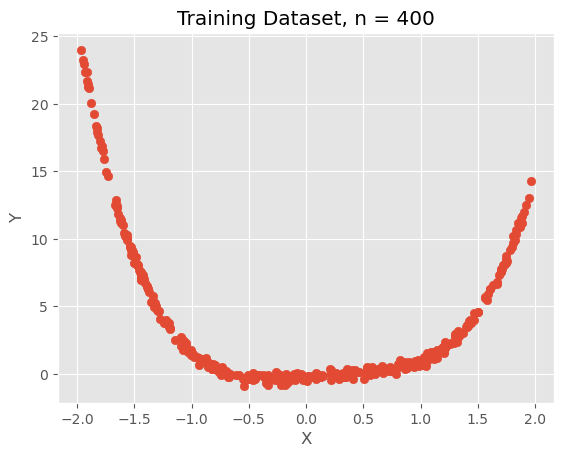

In [ ]:
plot1 = plt.scatter(x, y)
plt.title(f'Training Dataset, n = {x.size}')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=4, include_bias=False)
poly_features = poly.fit_transform(x.reshape(-1, 1))

In [ ]:
# poly.transform(x.reshape(-1, 1))

In [ ]:
from sklearn.linear_model import LinearRegression

poly_reg_model = LinearRegression()
poly_reg_model

LinearRegression()

In [ ]:
params = poly_reg_model.fit(poly_features, y)

y_predicted = poly_reg_model.predict(poly_features)
# print(y_predicted[:10])
# print(y[:10])


In [ ]:
d, c, b, a = params.coef_
print(a, b, c, d)
intercept = params.intercept_
print(params.intercept_)

1.2053934318561321 -0.8036620332156272 0.28989803950813753 0.5075934645790964
-0.21463817306568922


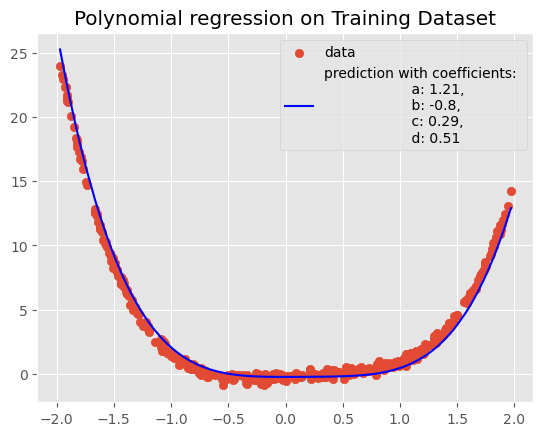

0.37636243729847907
-0.2143265593220836 -0.0974627443962723


In [ ]:


x_range = np.linspace(x.min(), x.max(), len(y_predicted))

x2 = np.sort(x)
y2 = np.sort(y)
pred = [a*x_i**4 + b*x_i**3 + c*x_i**2 + intercept for x_i in x2]

# plt.scatter(x, y)
a2, b2, c2, d2 = [round(i, 2) for i in [a, b, c, d]]
data = plt.scatter(x, y, label='data')
prediction = plt.plot(x2, pred, c='blue', label=f'''prediction with coefficients: 
                    a: {a2},
                    b: {b2},
                    c: {c2},
                    d: {d2}''')
plt.title('Polynomial regression on Training Dataset')
plt.legend()
plt.show()
# x_range
from sklearn.metrics import mean_squared_error

print(mean_squared_error(pred, y))

print(pred[200], y[200])


In [ ]:
validation_dataset = pd.read_csv('val.csv')
validation_dataset.sort_values('x', inplace=True)

x_val = validation_dataset.x.to_numpy()
y_val = validation_dataset.y.to_numpy()


0.35539139030909034
[24.72290428 20.68687923 19.54095344 19.26002405 18.8991202  18.28058664
 16.88303136 16.41649523 16.17440911 11.85033015] [25.604079983727704, 21.374969521909176, 20.21596641520981, 20.19943161724986, 19.56606968242702, 19.223214658497405, 17.82135436380387, 17.408774673126242, 17.01898728570702, 12.779206008896042]


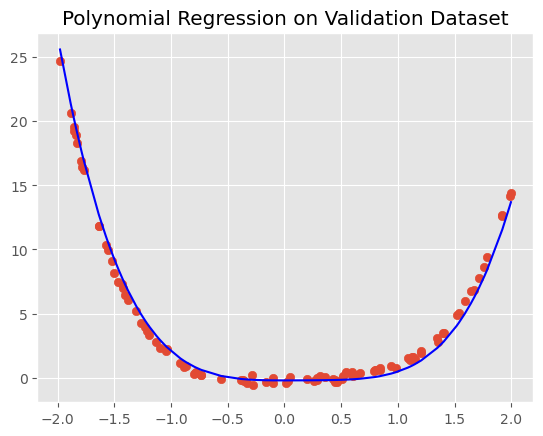

In [ ]:
pred = [a*x_i**4 + b*x_i**3 + c*x_i**2 + intercept for x_i in np.sort(x_val)]
plt.scatter(x_val, y_val)
plt.plot(np.sort(x_val), 
    pred,
    c='blue')

plt.title('Polynomial Regression on Validation Dataset')
print(mean_squared_error(pred,y_val))
print(y_val[:10], pred[:10])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

clf = MLPRegressor(activation='logistic', solver='adam', alpha=1e-5, learning_rate='constant',
                   learning_rate_init=0.001,
                   hidden_layer_sizes=(64, 64), random_state=1, max_iter=10_000)

clf.fit(x.reshape(-1, 1), y)


MLPRegressor(activation='logistic', alpha=1e-05, hidden_layer_sizes=(64, 64),
             max_iter=10000, random_state=1)

In [ ]:
y_true = y_test
y_pred  = clf.predict(x_test.reshape(-1, 1))
print(mean_squared_error(y_true, y_pred))
# print(y_test)


0.08541064028526574


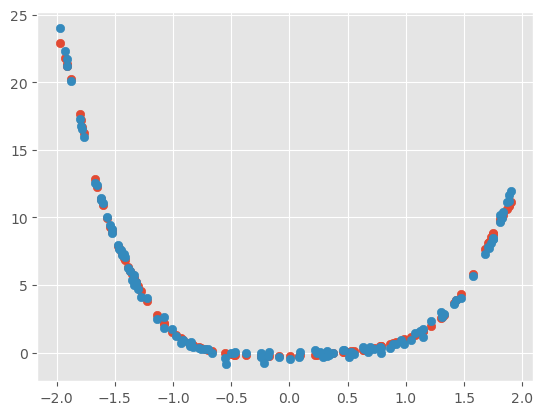

In [ ]:
plot_3_1 = plt.scatter(x_test, y_pred)
plot_3_2 = plt.scatter(x_test, y_true)

In [ ]:
validation_dataset = pd.read_csv('val.csv')

x_val = validation_dataset.x.to_numpy()
y_val = validation_dataset.y.to_numpy()


In [ ]:
y_val_pred = clf.predict(x_val.reshape(-1, 1))


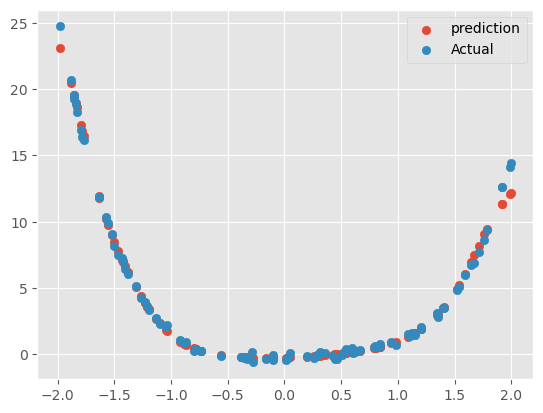

In [ ]:
plot_4_1 = plt.scatter(x_val, y_val_pred, label='prediction')
plot_4_2 = plt.scatter(x_val, y_val, label='Actual')
plt.legend()
plt.show()

In [ ]:

plt.show()

[ 1.34407042 -0.77210984 -0.10278485  0.51830356]
[ 3.80421612e-01  6.86078834e+00  1.61493147e+00  9.92923392e+00
  1.41354894e+01  4.85452891e+00  9.25548790e-01  3.09308445e+00
  1.03758256e+01  1.44102345e+01  3.27972390e-01  1.30712876e-01
  1.18503301e+01  5.95399585e+00  2.06868792e+01  2.24029875e+00
  7.27852390e+00  1.41634034e+00  3.65994997e+00  6.77369072e+00
  2.41800555e-01  1.92600241e+01  2.47229043e+01  1.68830314e+01
 -1.02327418e-01  1.89120964e+00  2.08233900e+00  3.48018999e+00
  1.61744091e+01  2.09540954e+00  7.73942265e+00  1.50349155e+00
  5.35561996e-01  2.80913208e+00  1.88991202e+01  3.31792680e+00
  8.17569903e+00 -3.99852851e-01  7.30285782e-01  1.26847359e-01
  3.49254837e+00  6.05359020e+00  9.27021003e-01  3.91451789e+00
  1.12216366e+00  6.36106897e-01  1.26562407e+01 -3.62283092e-01
  1.64164952e+01 -3.62831089e-01  1.82805866e+01  5.06296374e+00
  7.60442353e-01  5.19176657e+00  1.18445229e+01  4.25177795e+00
  1.26110073e+01 -3.75670281e-01  1.5821

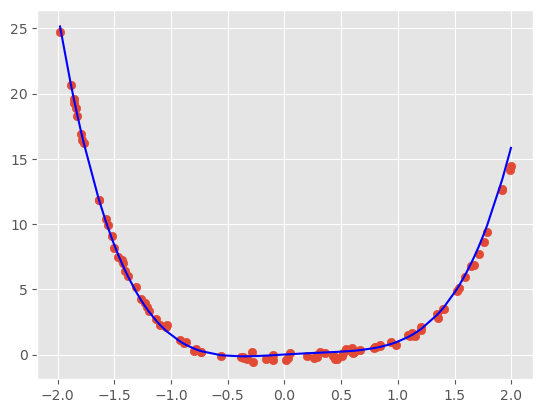

In [ ]:

A = [[i**4, i**3, i**2, i] for i in x_val]
Y = [i for i in y_val_pred]

res = np.linalg.inv(A[:4]).dot(Y[:4])
print(res)
x_val_2 = np.sort(x_val)
new_y_val_pred = [res[0]*i**4 + res[1]*i**3 + res[2]*i**2 + res[3]*i for i in x_val_2]
plt.plot(x_val_2, new_y_val_pred, c='blue')
plt.scatter(x_val, y_val, label='Actual')

print(y_val)
 